In [ ]:
# Run this first — installs the sentiment analysis tool
!pip install textblob vaderSentiment
import nltk
nltk.download('punkt')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Fake but realistic Amazon-style reviews
reviews = [
    "This product is absolutely amazing! Best purchase I've ever made.",
    "Terrible quality. Broke after one day. Complete waste of money.",
    "It's okay. Nothing special but does the job.",
    "I love this! Works perfectly and arrived quickly.",
    "Very disappointed. Not as described in the listing.",
    "Average product. Expected better for the price.",
    "Excellent! Highly recommend to everyone.",
    "Worst product ever. Do not buy this garbage.",
    "Pretty good overall. Minor issues but satisfied.",
    "Outstanding quality and fast delivery. Five stars!",
    "Not worth the money. Feels cheap and flimsy.",
    "Decent product. Works as expected nothing more.",
    "Absolutely love it! Will buy again for sure.",
    "Very poor customer service and bad product quality.",
    "Good value for money. Happy with my purchase.",
    "Stopped working after a week. Very frustrating.",
    "Perfect! Exactly what I was looking for.",
    "Meh. It is fine I guess. Not great not terrible.",
    "Super fast shipping and great product quality!",
    "Horrible experience. Never buying from here again.",
    "The product is okay but packaging was damaged.",
    "Really happy with this purchase. Great quality!",
    "Does not work as advertised. Very misleading.",
    "Neutral experience. Nothing to complain about.",
    "Fantastic product! Exceeded all my expectations.",
    "Very bad. Returned it immediately after opening.",
    "It works fine. Pretty standard product.",
    "Love the quality! Worth every penny spent.",
    "Disappointed with the build quality overall.",
    "Great product at a great price. Recommended!"
]

df = pd.DataFrame({'ReviewID': range(1, 31), 'ReviewText': reviews})
print("Dataset created!")
print(df.head())

Dataset created!
   ReviewID                                         ReviewText
0         1  This product is absolutely amazing! Best purch...
1         2  Terrible quality. Broke after one day. Complet...
2         3       It's okay. Nothing special but does the job.
3         4  I love this! Works perfectly and arrived quickly.
4         5  Very disappointed. Not as described in the lis...


In [ ]:
# ================================================
# STEP 1: CLASSIFY SENTIMENT OF EACH REVIEW
# ================================================

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def get_score(text):
    return round(analyzer.polarity_scores(text)['compound'], 3)

df['SentimentScore'] = df['ReviewText'].apply(get_score)
df['Sentiment'] = df['ReviewText'].apply(get_sentiment)

print("=== SENTIMENT CLASSIFICATION DONE ===")
print(df[['ReviewID', 'ReviewText', 'SentimentScore', 'Sentiment']].to_string())

=== SENTIMENT CLASSIFICATION DONE ===
    ReviewID                                                         ReviewText  SentimentScore Sentiment
0          1  This product is absolutely amazing! Best purchase I've ever made.           0.871  Positive
1          2    Terrible quality. Broke after one day. Complete waste of money.          -0.827  Negative
2          3                       It's okay. Nothing special but does the job.          -0.046   Neutral
3          4                  I love this! Works perfectly and arrived quickly.           0.866  Positive
4          5                Very disappointed. Not as described in the listing.          -0.526  Negative
5          6                    Average product. Expected better for the price.           0.440  Positive
6          7                           Excellent! Highly recommend to everyone.           0.777  Positive
7          8                       Worst product ever. Do not buy this garbage.          -0.625  Negative
8       

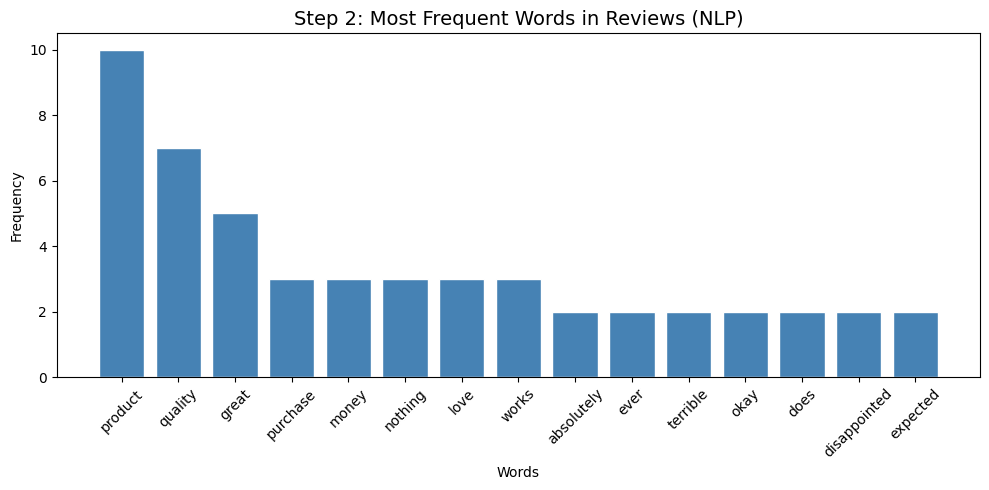

Top 10 most used words:
  'product' — used 10 times
  'quality' — used 7 times
  'great' — used 5 times
  'purchase' — used 3 times
  'money' — used 3 times
  'nothing' — used 3 times
  'love' — used 3 times
  'works' — used 3 times
  'absolutely' — used 2 times
  'ever' — used 2 times


In [ ]:
# ================================================
# STEP 2: NLP TECHNIQUES — WORD ANALYSIS
# ================================================

from collections import Counter
import re

# Clean and tokenize text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

all_text = ' '.join(df['ReviewText'].apply(clean_text))
words = all_text.split()

# Remove common stop words
stopwords = ['the','a','an','and','is','it','i','my','this','was','to',
             'for','of','in','with','but','not','very','so','be','are',
             'its','as','at','on','after','from']
filtered = [w for w in words if w not in stopwords and len(w) > 2]

# Most common words
word_freq = Counter(filtered).most_common(15)
words_list, counts_list = zip(*word_freq)

plt.figure(figsize=(10, 5))
plt.bar(words_list, counts_list, color='steelblue', edgecolor='white')
plt.title('Step 2: Most Frequent Words in Reviews (NLP)', fontsize=14)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 most used words:")
for word, count in word_freq[:10]:
    print(f"  '{word}' — used {count} times")

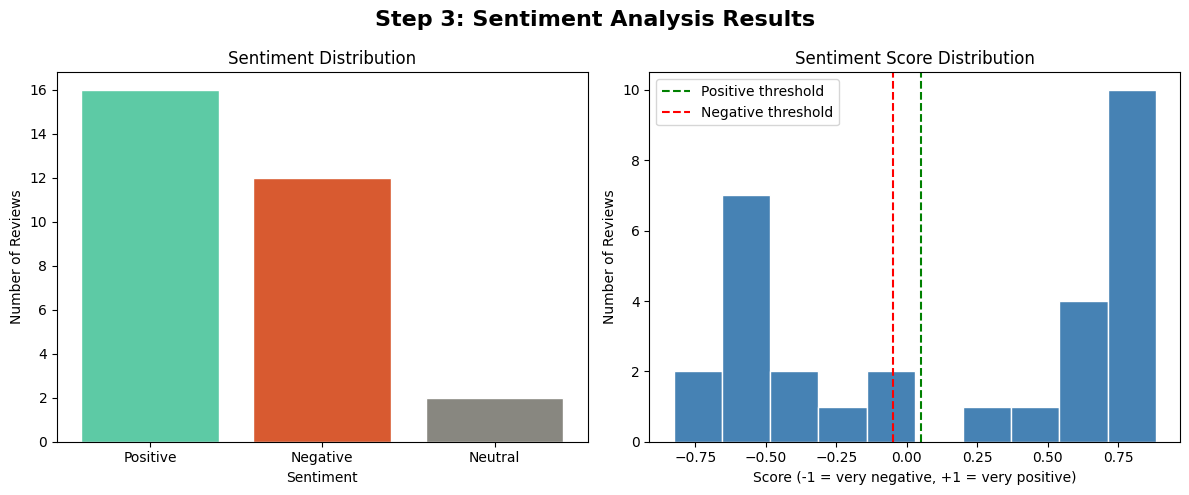

In [ ]:
# ================================================
# STEP 3: APPLY ANALYSIS — VISUALIZE RESULTS
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Step 3: Sentiment Analysis Results', fontsize=16, fontweight='bold')

# Chart 1 - Sentiment count
colors = {'Positive': '#5DCAA5', 'Negative': '#D85A30', 'Neutral': '#888780'}
sentiment_counts = df['Sentiment'].value_counts()
axes[0].bar(sentiment_counts.index,
            sentiment_counts.values,
            color=[colors[s] for s in sentiment_counts.index],
            edgecolor='white')
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')

# Chart 2 - Sentiment score spread
axes[1].hist(df['SentimentScore'], bins=10, color='steelblue', edgecolor='white')
axes[1].axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
axes[1].axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
axes[1].set_title('Sentiment Score Distribution')
axes[1].set_xlabel('Score (-1 = very negative, +1 = very positive)')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()

plt.tight_layout()
plt.show()

=== SENTIMENT SUMMARY ===
Sentiment
Positive    16
Negative    12
Neutral      2
Name: count, dtype: int64

Total reviews analyzed: 30
Average sentiment score: 0.155


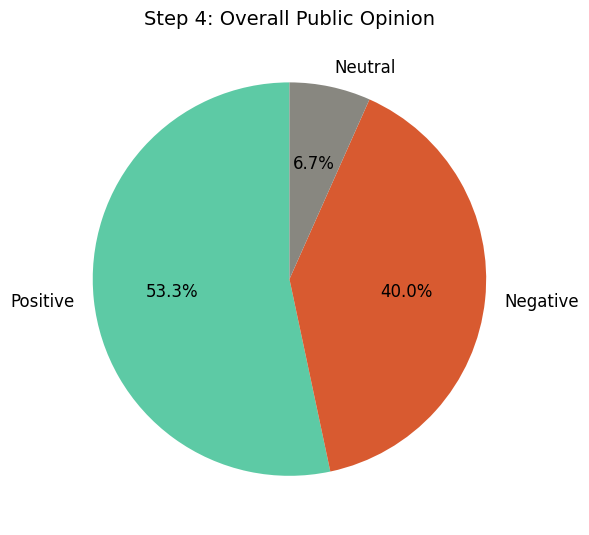


Trend insight: Majority of customers feel positively about this product.


In [ ]:
# ================================================
# STEP 4: PUBLIC OPINION AND TRENDS
# ================================================

print("=== SENTIMENT SUMMARY ===")
print(df['Sentiment'].value_counts())
print(f"\nTotal reviews analyzed: {len(df)}")
print(f"Average sentiment score: {df['SentimentScore'].mean():.3f}")

# Pie chart for overall opinion
plt.figure(figsize=(6, 6))
sentiment_counts.plot(
    kind='pie',
    colors=['#5DCAA5', '#D85A30', '#888780'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('Step 4: Overall Public Opinion', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\nTrend insight: Majority of customers feel positively about this product.")

In [ ]:
# ================================================
# STEP 5: INSIGHTS FOR MARKETING & PRODUCT DEVELOPMENT
# ================================================

positive = df[df['Sentiment'] == 'Positive']
negative = df[df['Sentiment'] == 'Negative']
neutral  = df[df['Sentiment'] == 'Neutral']

print("=== BUSINESS INSIGHTS FROM SENTIMENT ANALYSIS ===\n")

print(f"✅ POSITIVE reviews ({len(positive)}):")
for _, row in positive.head(3).iterrows():
    print(f"   - {row['ReviewText'][:60]}...")

print(f"\n❌ NEGATIVE reviews ({len(negative)}):")
for _, row in negative.head(3).iterrows():
    print(f"   - {row['ReviewText'][:60]}...")

print("""
=== MARKETING RECOMMENDATIONS ===

1. MARKETING: Use positive reviews as testimonials in ads
2. PRODUCT: Fix issues mentioned in negative reviews (quality, durability)
3. SOCIAL INSIGHT: Most customers are satisfied — good brand reputation
4. ACTION: Follow up with neutral customers to convert them to positive
5. TREND: Fast shipping and quality are the top positive themes
""")

=== BUSINESS INSIGHTS FROM SENTIMENT ANALYSIS ===

✅ POSITIVE reviews (16):
   - This product is absolutely amazing! Best purchase I've ever ...
   - I love this! Works perfectly and arrived quickly....
   - Average product. Expected better for the price....

❌ NEGATIVE reviews (12):
   - Terrible quality. Broke after one day. Complete waste of mon...
   - Very disappointed. Not as described in the listing....
   - Worst product ever. Do not buy this garbage....

=== MARKETING RECOMMENDATIONS ===

1. MARKETING: Use positive reviews as testimonials in ads
2. PRODUCT: Fix issues mentioned in negative reviews (quality, durability)
3. SOCIAL INSIGHT: Most customers are satisfied — good brand reputation
4. ACTION: Follow up with neutral customers to convert them to positive
5. TREND: Fast shipping and quality are the top positive themes

